# **Introduction**
Dataset Name: NCR Ride Bookings Dataset   (National Capital Region)

Description:

This dataset contains 150,000 ride booking records from a ride-hailing/transportation platform in the NCR region.

It captures detailed information about bookings, ride status, customer/driver behavior, trip metrics, ratings, cancellations, and payment methods.

**IMPORT LIB**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**IMPORT DATASET**

In [12]:
booking=pd.read_csv('ncr.csv')

# **Data** **Understanding**

HEAD

it show first 5 rows in this dataset.

To preview the data and understand its structure.

In [13]:
booking.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


this is show last 5 rows in this dataset

In [14]:
booking.tail()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
105020,19-10-2024,07:47:18,"""CNR9337325""",Completed,"""CID2819000""",Auto,Tagore Garden,Gurgaon Sector 29,7.2,44.9,...,NaN,NaN,NaN,NaN,NaN,294.0,13.20,3.2,5.0,UPI
105021,20-07-2024,22:00:50,"""CNR4396389""",Completed,"""CID7837303""",Bike,Noida Sector 62,IIT Delhi,6.8,27.7,...,NaN,NaN,NaN,NaN,NaN,514.0,13.03,4.5,4.8,Cash
105022,06-02-2024,19:58:16,"""CNR4580345""",Cancelled by Customer,"""CID5160112""",Auto,Jor Bagh,Anand Vihar,15.5,NaN,...,Change of plans,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105023,02-12-2024,18:32:35,"""CNR8969991""",Completed,"""CID3310450""",Go Sedan,Gwal Pahari,RK Puram,4.3,43.1,...,NaN,NaN,NaN,NaN,NaN,85.0,49.44,5.0,4.6,UPI
105024,07-09-2024,23:32:42,"""CNR5975486""",No Driver Found,"""CID7921829""",Premier Sedan,Vinobapuri,Noida Sector 18,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


SHAPE

To know the number of rows and columns.

In [15]:
booking.shape

(105025, 21)

column

To identify available features

In [16]:
booking.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

info

To verify each column’s and their data type.

In [17]:
booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105025 entries, 0 to 105024
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               105025 non-null  object 
 1   Time                               105025 non-null  object 
 2   Booking ID                         105025 non-null  object 
 3   Booking Status                     105025 non-null  object 
 4   Customer ID                        105025 non-null  object 
 5   Vehicle Type                       105025 non-null  object 
 6   Pickup Location                    105025 non-null  object 
 7   Drop Location                      105025 non-null  object 
 8   Avg VTAT                           97645 non-null   float64
 9   Avg CTAT                           71410 non-null   float64
 10  Cancelled Rides by Customer        7307 non-null    float64
 11  Reason for cancelling by Customer  7307

# **Data** **Cleaning**

isnull

To identify columns with incomplete data.

it show the column null values count

In [18]:
booking.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,7380
Avg CTAT,33615


total missing values

In [19]:
booking.isnull().sum().sum()

np.int64(786750)

fillna

To treat missing data by filling, removing, or keeping it appropriately.

In [20]:
booking['Avg CTAT']=booking['Avg CTAT'].fillna(booking['Avg CTAT'].median())

In [21]:
booking['Avg VTAT']=booking['Avg VTAT'].fillna(booking['Avg VTAT'].median())

In [22]:
booking['Booking Value']=booking['Booking Value'].fillna(booking['Booking Value'].median())

In [23]:
booking['Ride Distance']=booking['Ride Distance'].fillna(booking['Ride Distance'].median())

In [24]:
booking['Driver Ratings']=booking['Driver Ratings'].fillna(3.9)

In [25]:
booking['Customer Rating']=booking['Customer Rating'].fillna(5)

In [26]:
booking['Payment Method']=booking['Payment Method'].fillna('Gpay')

**remove unwanted** **column**

In [27]:
booking.drop([
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason'
], axis=1, inplace=True)

Now check null values

In [28]:
booking.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,0
Avg CTAT,0


check column and data type

In [29]:
booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105025 entries, 0 to 105024
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date             105025 non-null  object 
 1   Time             105025 non-null  object 
 2   Booking ID       105025 non-null  object 
 3   Booking Status   105025 non-null  object 
 4   Customer ID      105025 non-null  object 
 5   Vehicle Type     105025 non-null  object 
 6   Pickup Location  105025 non-null  object 
 7   Drop Location    105025 non-null  object 
 8   Avg VTAT         105025 non-null  float64
 9   Avg CTAT         105025 non-null  float64
 10  Booking Value    105025 non-null  float64
 11  Ride Distance    105025 non-null  float64
 12  Driver Ratings   105025 non-null  float64
 13  Customer Rating  105025 non-null  float64
 14  Payment Method   105025 non-null  object 
dtypes: float64(6), object(9)
memory usage: 12.0+ MB


dupicated

To eliminate repeated records.

In [30]:
booking.duplicated().sum()

np.int64(0)

Fix data types

In [31]:

booking['Date'] = pd.to_datetime(booking['Date'])

booking['Time'] = pd.to_datetime(booking['Time']).dt.time

booking['Booking Status'] = booking['Booking Status'].astype('category')
booking['Vehicle Type'] = booking['Vehicle Type'].astype('category')
booking['Pickup Location'] = booking['Pickup Location'].astype('category')
booking['Drop Location'] = booking['Drop Location'].astype('category')
booking['Payment Method'] = booking['Payment Method'].astype('category')

booking['Booking Value'] = booking['Booking Value'].astype('Int64')

/tmp/ipykernel_9843/1084686720.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  booking['Date'] = pd.to_datetime(booking['Date'])
/tmp/ipykernel_9843/1084686720.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  booking['Time'] = pd.to_datetime(booking['Time']).dt.time


In [32]:
booking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105025 entries, 0 to 105024
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Date             105025 non-null  datetime64[ns]
 1   Time             105025 non-null  object        
 2   Booking ID       105025 non-null  object        
 3   Booking Status   105025 non-null  category      
 4   Customer ID      105025 non-null  object        
 5   Vehicle Type     105025 non-null  category      
 6   Pickup Location  105025 non-null  category      
 7   Drop Location    105025 non-null  category      
 8   Avg VTAT         105025 non-null  float64       
 9   Avg CTAT         105025 non-null  float64       
 10  Booking Value    105025 non-null  Int64         
 11  Ride Distance    105025 non-null  float64       
 12  Driver Ratings   105025 non-null  float64       
 13  Customer Rating  105025 non-null  float64       
 14  Payment Method   105

# **Statistical Summary**

describe

math functions

In [33]:
booking.describe()

,Date,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,105025,105025.000000,105025.000000,105025.0,105025.000000,105025.000000,105025.000000
mean,2024-06-30 19:20:07.838134016,8.452290,29.035368,477.856482,24.363967,4.105640,4.629548
min,2024-01-01 00:00:00,2.000000,10.000000,50.0,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,5.600000,25.000000,320.0,17.380000,3.900000,4.300000
50%,2024-07-01 00:00:00,8.300000,28.800000,414.0,23.750000,3.900000,4.800000
75%,2024-09-30 00:00:00,11.000000,32.900000,521.0,30.680000,4.300000,5.000000
max,2024-12-30 00:00:00,20.000000,45.000000,4277.0,50.000000,5.000000,5.000000
std,NaN,3.644943,7.345042,328.335865,11.553628,0.379848,0.450921


unique and their count

In [34]:
for location in booking['Vehicle Type'].unique():
    print(location)

eBike
Go Sedan
Auto
Premier Sedan
Bike
Go Mini
Uber XL


In [35]:
booking['Vehicle Type'].value_counts()

,count
Vehicle Type,
Auto,26218
Go Mini,20659
Go Sedan,19082
Bike,15800
Premier Sedan,12667
eBike,7447
Uber XL,3152


In [36]:
for location in booking['Booking Status'].unique():
    print(location)

No Driver Found
Incomplete
Completed
Cancelled by Driver
Cancelled by Customer


In [37]:
booking['Booking Status'].value_counts()

,count
Booking Status,
Completed,65125
Cancelled by Driver,18928
No Driver Found,7380
Cancelled by Customer,7307
Incomplete,6285


In [38]:
booking['Payment Method']=booking['Payment Method'].value_counts()

In [39]:
for location in booking['Pickup Location'].unique():
    print(location)

Palam Vihar
Shastri Nagar
Khandsa
Central Secretariat
Ghitorni Village
AIIMS
Vaishali
Mayur Vihar
Noida Sector 62
Rohini
Udyog Bhawan
Vidhan Sabha
Patel Chowk
Malviya Nagar
Madipur
Jama Masjid
IGI Airport
Vinobapuri
Kashmere Gate
Pitampura
Punjabi Bagh
Greater Noida
Tis Hazari
Noida Sector 18
Kanhaiya Nagar
Okhla
Cyber Hub
Sadar Bazar Gurgaon
Shastri Park
Faridabad Sector 15
Qutub Minar
Mundka
DLF City Court
New Colony
Nirman Vihar
New Delhi Railway Station
Civil Lines Gurgaon
Seelampur
Noida Extension
Adarsh Nagar
Panipat
Karol Bagh
Sultanpur
Moti Nagar
Dilshad Garden
Aya Nagar
Rajiv Chowk
MG Road
Jasola
Ardee City
Meerut
Anand Vihar ISBT
Lajpat Nagar
Tughlakabad
Karkarduma
Dwarka Mor
Anand Vihar
Uttam Nagar
Model Town
Mandi House
Ghitorni
Rajiv Nagar
Sohna Road
Bahadurgarh
Moolchand
INA Market
Sushant Lok
IIT Delhi
Satguru Ram Singh Marg
Munirka
IGNOU Road
Akshardham
Chhatarpur
IMT Manesar
Azadpur
Jhilmil
Sikanderpur
Rohini West
Kashmere Gate ISBT
Kherki Daula Toll
IFFCO Chowk
Hauz R

In [40]:
for location in booking['Drop Location'].unique():
    print(location)

Jhilmil
Gurgaon Sector 56
Malviya Nagar
Inderlok
Khan Market
Narsinghpur
Punjabi Bagh
Cyber Hub
Noida Sector 18
Adarsh Nagar
Dwarka Sector 21
AIIMS
Kherki Daula Toll
Ghitorni Village
GTB Nagar
Madipur
Anand Vihar
Rajiv Nagar
Mansarovar Park
Botanical Garden
IMT Manesar
Old Gurgaon
Barakhamba Road
Saket
Mehrauli
Vishwavidyalaya
Preet Vihar
Nehru Place
Shahdara
Noida Film City
Mandi House
Janakpuri
Udyog Vihar Phase 4
Civil Lines Gurgaon
Karkarduma
Tagore Garden
Noida Extension
Anand Vihar ISBT
Central Secretariat
Hauz Rani
Palam Vihar
RK Puram
Basai Dhankot
Badarpur
Ramesh Nagar
Akshardham
Yamuna Bank
IGI Airport
New Colony
Green Park
ITO
New Delhi Railway Station
Mundka
India Gate
Pitampura
Netaji Subhash Place
Indraprastha
Rohini
Chirag Delhi
Pataudi Chowk
Karol Bagh
Vaishali
IFFCO Chowk
Noida Sector 62
Gwal Pahari
Saidulajab
Jasola
Tis Hazari
Udyog Bhawan
Saket A Block
Mayur Vihar
Gurgaon Sector 29
Ashram
DLF City Court
Badshahpur
DLF Phase 3
Greater Noida
IGNOU Road
Bahadurgarh
Chan

IQR

To detect outliers in numerical data

To understand the spread of the middle 50% of values

To identify unusually high or low observations

In [41]:
Q1 = booking['Booking Value'].quantile(0.25)
Q3 = booking['Booking Value'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 320.0
Q3: 521.0
IQR: 201.0
Lower Bound: 18.5
Upper Bound: 822.5


Average Revenue per Ride

In [42]:
avg_revenue = booking['Booking Value'].mean()

print("Average Revenue per Ride:", round(avg_revenue, 2))

Average Revenue per Ride: 477.86


Revenue per KM

In [43]:
revenue_per_km = (
    booking['Booking Value'].sum() / booking['Ride Distance'].sum()
)

print("Revenue per KM:", round(revenue_per_km, 2))

Revenue per KM: 19.61


Average Wait Time

In [44]:
avg_wait_time = booking['Avg VTAT'].mean()

print("Average Wait Time:", round(avg_wait_time, 2), "minutes")

Average Wait Time: 8.45 minutes


Rating vs Wait Time

In [45]:
booking[['Customer Rating', 'Avg VTAT']].corr().round(2)


,Customer Rating,Avg VTAT
Customer Rating,1.00,-0.02
Avg VTAT,-0.02,1.00


Best/Worst Rated Vehicle Types

In [46]:
booking.groupby('Vehicle Type')['Customer Rating'].mean().sort_values(ascending=False).round(2)

/tmp/ipykernel_9843/2226241174.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  booking.groupby('Vehicle Type')['Customer Rating'].mean().sort_values(ascending=False).round(2)


,Customer Rating
Vehicle Type,
Go Sedan,4.64
eBike,4.63
Bike,4.63
Premier Sedan,4.63
Auto,4.63
Go Mini,4.62
Uber XL,4.62


date and time that convert one column

In [47]:


booking['Date'] = pd.to_datetime(booking['Date'])


booking['DateTime'] = pd.to_datetime(
    booking['Date'].astype(str) + ' ' + booking['Time'].astype(str)
)


booking[['Date', 'Time', 'DateTime']].head()

,Date,Time,DateTime
0,2024-03-23,12:29:38,2024-03-23 12:29:38
1,2024-11-29,18:01:39,2024-11-29 18:01:39
2,2024-08-23,08:56:10,2024-08-23 08:56:10
3,2024-10-21,17:17:25,2024-10-21 17:17:25
4,2024-09-16,22:08:00,2024-09-16 22:08:00


In [48]:
booking.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,414,23.75,3.9,5.0,NaN,2024-03-23 12:29:38
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,237,5.73,3.9,5.0,NaN,2024-11-29 18:01:39
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,627,13.58,4.9,4.9,NaN,2024-08-23 08:56:10
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,416,34.02,4.6,5.0,NaN,2024-10-21 17:17:25
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,737,48.21,4.1,4.3,NaN,2024-09-16 22:08:00


# **Univariate Analysis**

01)What is the distribution of booking statuses?



/tmp/ipykernel_9843/1189834583.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Booking Status',data=booking,palette='Set2')


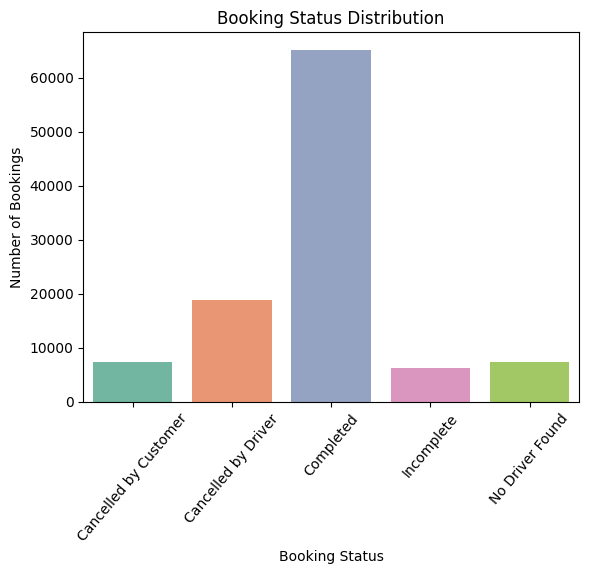

In [49]:
sns.countplot(x='Booking Status',data=booking,palette='Set2')
plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=50)

plt.show()

**Insights**

Most bookings are completed successfully

Some bookings are cancelled (customer/driver)

A small number of rides are incomplete


**Recommendations**

Reduce cancellations by improving service time

Train drivers to avoid unnecessary cancellations

Improve system to reduce incomplete rides

02)Which vehicle types are most frequently booked?


/tmp/ipykernel_9843/1834654069.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Vehicle Type', data=booking,palette='viridis')


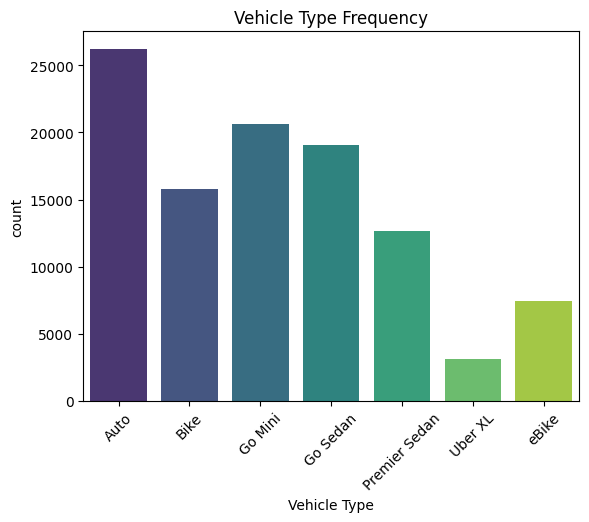

In [50]:
sns.countplot(x='Vehicle Type', data=booking,palette='viridis')
plt.title('Vehicle Type Frequency')
plt.xticks(rotation=45)
plt.show()

**Insights**

One vehicle type has highest demand

Some vehicle types have low usage

Demand is not equal across all vehicle types



**Recommendations**

Increase availability of high-demand vehicle type

Promote low-demand vehicles with offers

Balance fleet based on customer preference

03)Completed vs Cancelled vs Incomplete


<Axes: ylabel='count'>

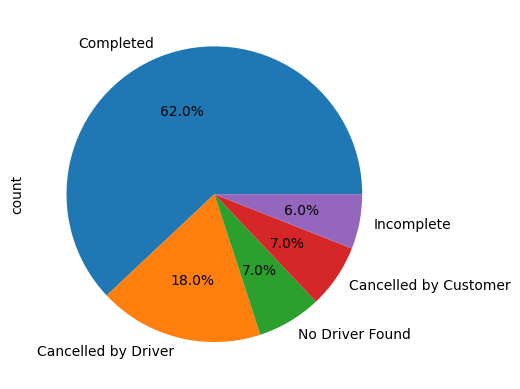

In [51]:
booking['Booking Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')

**Insights**

Majority of bookings are completed

A noticeable portion is cancelled

Very few rides are incomplete



**Recommendations**

Reduce cancellations by improving driver availability

Improve service speed to increase completed rides

Fix operational issues to reduce incomplete rides

04)How are ride distances distributed across bookings?


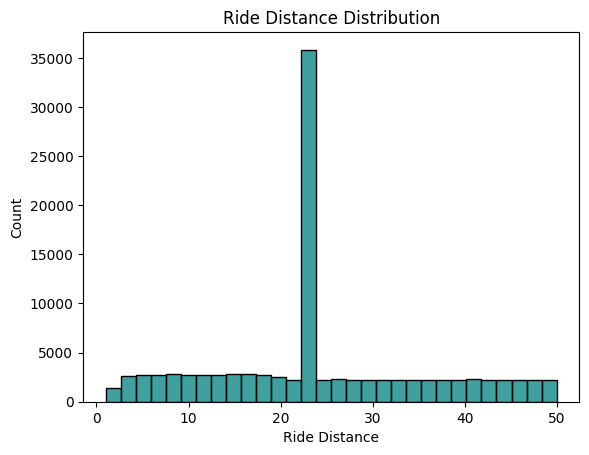

In [52]:
sns.histplot(booking['Ride Distance'], bins=30,color='teal')
plt.title('Ride Distance Distribution')
plt.xlabel('Ride Distance')
plt.show()

**Insights**

Most rides are short-distance

Few rides are long-distance

Data is skewed toward shorter trips



**Recommendations**

Focus on quick service for short rides

Offer incentives for long-distance rides

Optimize pricing based on distance demand

05)How is booking value/fare distributed?

In [53]:
fig = px.histogram(
    booking,
    x='Booking Value',
    nbins=30,
    marginal='box',
    title='Booking Value Distribution',
    color_discrete_sequence=['brown']
)

fig.update_layout(
    xaxis_title='Booking Value',
    yaxis_title='Count'
)

fig.show()

**Insights**

Most bookings are in a low to medium price range

Few bookings have very high values (outliers)

Pricing distribution is uneven (skewed)


**Recommendations**

Focus on affordable pricing for more customers

Analyze high-value rides for premium services

Use dynamic pricing to balance demand

# **Bivariate Analysis**

01)Cancellations by Vehicle Type


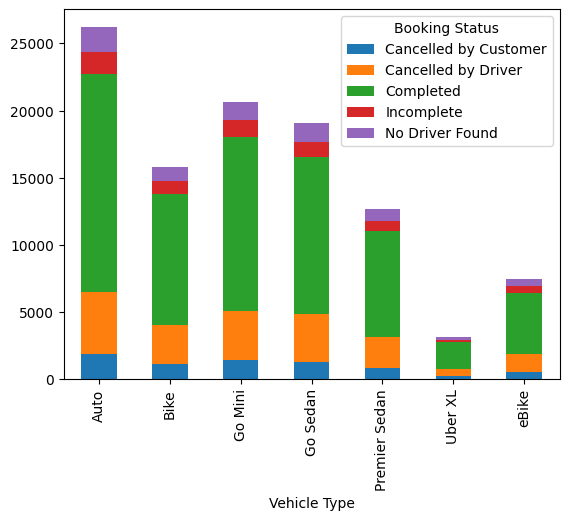

In [54]:
pd.crosstab(booking['Vehicle Type'],booking['Booking Status']).plot(kind='bar', stacked=True)
plt.show()

**Insights**

Some vehicle types have more completed rides

Certain vehicle types show higher cancellations

Performance differs across vehicle categories



**Recommendations**

Improve service for vehicles with high cancellations

Increase availability of high-performing vehicle types

Monitor and manage performance by vehicle category

02)Correlation Heatmap


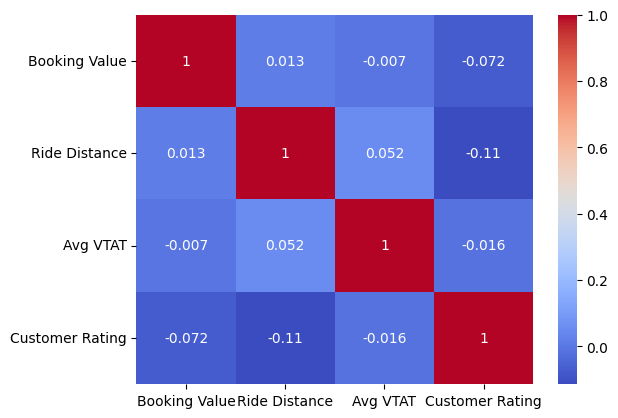

In [55]:
sns.heatmap(
    booking[['Booking Value','Ride Distance','Avg VTAT','Customer Rating']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

**Insights**

Some variables show positive correlation (increase together)

Some variables show negative correlation (one increases, other decreases)

Weak correlation means little or no relationship


**Recommendations**

Focus on factors that strongly affect booking value

Reduce delay (VTAT) to improve customer rating

Use important variables for better decision making

03)How does booking value vary across different vehicle types?


In [56]:
import plotly.express as px

fig = px.box(
    booking,
    x='Vehicle Type',
    y='Booking Value',
    title='Booking Value by Vehicle Type',
    color='Vehicle Type'
)

fig.show()

**Insights**

Booking values vary across vehicle types

Some vehicle types have higher price ranges

Presence of outliers (very high/low values)



**Recommendations**

Focus on high-value vehicle types for better revenue

Review outliers to ensure correct pricing

Adjust pricing strategy based on vehicle category

04)Ride Distance vs Booking Value

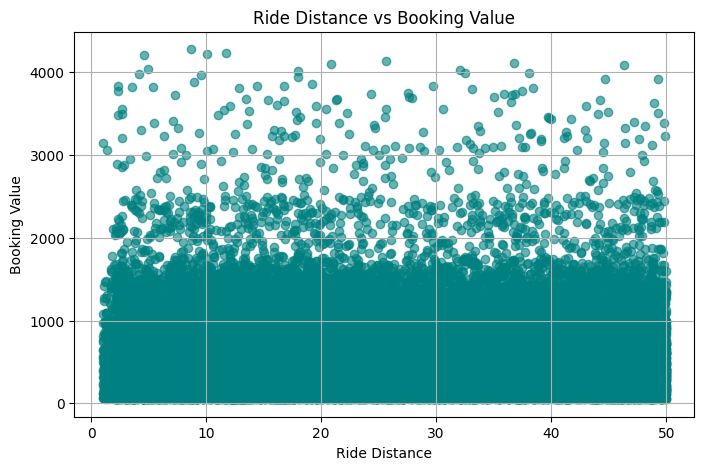

In [57]:
plt.figure(figsize=(8,5))
plt.scatter(booking['Ride Distance'], booking['Booking Value'], alpha=0.6, color='teal')
plt.xlabel("Ride Distance")
plt.ylabel("Booking Value")
plt.title("Ride Distance vs Booking Value")
plt.grid(True)
plt.show()

**Insights**

Booking value generally increases with ride distance

There is a positive relationship between distance and price

Some points may not follow the pattern (outliers)


**Recommendations**

Maintain fair pricing based on distance

Check outliers to avoid incorrect pricing

Use distance-based pricing for better consistency

# **trend comparisons**

Month over month

In [58]:

booking['Date'] = pd.to_datetime(booking['Date'])

booking['Month'] = booking['Date'].dt.to_period('M').astype(str)


mom_revenue = booking.groupby('Month')['Booking Value'].sum().reset_index()


fig = px.line(
    mom_revenue,
    x='Month',
    y='Booking Value',
    markers=True,
    title='Month-over-Month Revenue Trend'
)


fig.update_traces(line=dict(color='teal', width=3))
fig.update_layout(
    xaxis_title='Month',
    yaxis_title='Total Revenue'
)

fig.show()

**Insights**

Revenue shows increase or decrease across months

Some months generate higher revenue (peak months)

Revenue trend may be fluctuating or growing



**Recommendations**

Focus on peak months to maximize revenue

Use offers in low months to increase sales

Plan resources based on monthly demand

In [59]:
booking['Date'] = pd.to_datetime(booking['Date'])


daily_revenue = booking.groupby('Date')['Booking Value'].sum().reset_index()


fig = px.line(
    daily_revenue,
    x='Date',
    y='Booking Value',
    markers=True,
    title='Daily Revenue Trend'
)


fig.update_traces(line=dict(color='teal', width=3))
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Total Revenue'
)

fig.show()

**Insights**

Revenue changes day by day

Some days show higher revenue (peak days)

Revenue may be increasing, decreasing, or fluctuating


**Recommendations**

Increase drivers on high-revenue days

Offer discounts on low-revenue days

Monitor daily performance to improve consistency

# **Hypothesis Testing**

**T-Test**

compare the mean of a numeric variable between two groups.

Compare Booking Value Between Two Payment Methods

In [60]:
from scipy.stats import ttest_ind

cash = booking[booking['Payment Method'] == 'Cash']['Booking Value']
upi = booking[booking['Payment Method'] == 'UPI']['Booking Value']

t_stat, p_value = ttest_ind(cash, upi, nan_policy='omit')

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: nan
P-Value: nan


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



**Monthly Ride Demand Trend**

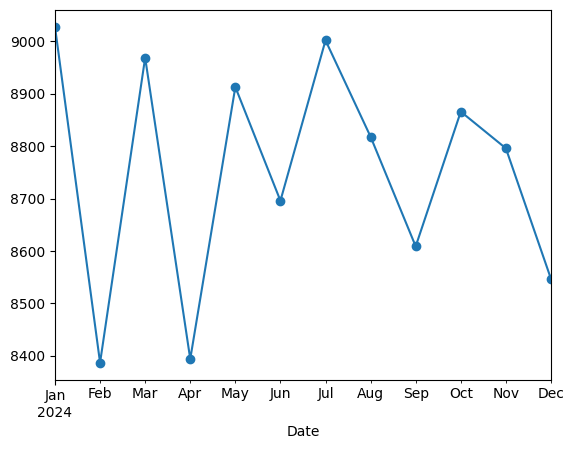

In [71]:
monthly_trend = booking.groupby(booking['Date'].dt.to_period('M')).size()
monthly_trend.plot(kind='line', marker='o')
plt.show()

**Insights**

Bookings increase in some months and decrease in others

There are peak months with high demand

Demand is not constant (fluctuating trend)


**Recommendations**

Add more drivers during peak months

Give offers in low-demand months

Improve service to maintain steady bookings

# **Conclusion**

The analysis provided insights into booking patterns, customer preferences, cancellations, revenue, and service performance.

Vehicle type, booking status, payment methods, and ride metrics helped identify key operational trends.

Cancellation and wait-time analysis highlighted areas for service improvement.

Revenue and booking trends revealed opportunities for better resource allocation.

Overall, the analysis can help improve customer satisfaction, operational efficiency, and business decision-making.